# PM2.5 Enriched Dataset V4 (2023-2025) - Comprehensive EDA

Analysis of the enriched PM2.5 dataset combining air quality, traffic, and weather data for June 2023 - June 2025.

**Version**: V4 - Multi-year analysis with complete feature set

## 1. Setup and Data Loading

In [ ]:
data_path = '/Users/vojtech/Code/Bard89/smoglens-02/voi/v4_multiyear_oAQ_oM_J/'
df = pd.read_csv(f'{data_path}pm25_enriched_2023_2025_v4_20250830_222050.csv', parse_dates=['timestamp'])

In [2]:
data_path = '/Users/vojtech/Code/Bard89/smoglens-02/voi/V4_enrichement_OPEANAQ_OPENMETEO_JARTIC/'

csv_files = glob.glob(os.path.join(data_path, 'pm25_enriched_2023_2025_v4*.csv'))

file_to_load = sorted(csv_files)[-1]
print(f"Loading: {os.path.basename(file_to_load)}")

df = pd.read_csv(file_to_load, parse_dates=['timestamp'])

print(f"\nDataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"\nColumns ({len(df.columns)}): {list(df.columns)}")

Loading: pm25_enriched_2023_2025_v4_20250830_222050.csv

Dataset shape: 9,457,112 rows × 39 columns
Memory usage: 3.56 GB

Columns (39): ['timestamp', 'hex7_id', 'lat', 'lon', 'pm25_ugm3_mean', 'pm25_ugm3_min', 'pm25_ugm3_max', 'pm25_ugm3_count', 'pm25_range', 'avg_traffic_volume', 'max_traffic_volume', 'avg_speed_kmh', 'congestion_index', 'unique_links', 'traffic_measurement_count', 'traffic_distance_km', 'traffic_intensity', 'temperature_c_mean', 'humidity_pct_mean', 'precipitation_mm_mean', 'pressure_hpa_mean', 'cloud_cover_pct_mean', 'dew_point_c_mean', 'solar_radiation_wm2_mean', 'weather_distance_km', 'heat_index', 'is_raining', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'data_completeness_score']


In [3]:
print("Data types:")
display(df.dtypes)

print("\nFirst 10 rows:")
display(df.head(10))

print("\nLast 10 rows:")
display(df.tail(10))

Data types:


timestamp                    datetime64[ns, UTC]
hex7_id                                   object
lat                                      float64
lon                                      float64
pm25_ugm3_mean                           float64
pm25_ugm3_min                            float64
pm25_ugm3_max                            float64
pm25_ugm3_count                            int64
pm25_range                               float64
avg_traffic_volume                       float64
max_traffic_volume                       float64
avg_speed_kmh                            float64
congestion_index                         float64
unique_links                             float64
traffic_measurement_count                float64
traffic_distance_km                      float64
traffic_intensity                          int64
temperature_c_mean                       float64
humidity_pct_mean                        float64
precipitation_mm_mean                    float64
pressure_hpa_mean   


First 10 rows:


,timestamp,hex7_id,lat,lon,pm25_ugm3_mean,pm25_ugm3_min,pm25_ugm3_max,pm25_ugm3_count,pm25_range,avg_traffic_volume,max_traffic_volume,avg_speed_kmh,congestion_index,unique_links,traffic_measurement_count,traffic_distance_km,traffic_intensity,temperature_c_mean,humidity_pct_mean,precipitation_mm_mean,pressure_hpa_mean,cloud_cover_pct_mean,dew_point_c_mean,solar_radiation_wm2_mean,weather_distance_km,heat_index,is_raining,hour,day_of_week,month,year,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,data_completeness_score
0,2023-07-14 16:00:00+00:00,872e0122effffff,39.27,141.85,6.00,6.00,6.00,1,0.00,2.59,9.41,58.71,0.94,10.41,124.40,3.90,0,24.30,90.76,1.09,1004.48,100.00,22.63,0.37,139.27,24.30,1,16,4,7,2023,0,-0.87,-0.50,-0.43,-0.90,-0.50,-0.87,1.00
1,2023-07-21 19:00:00+00:00,872e0122effffff,39.27,141.85,5.00,5.00,5.00,1,0.00,3.49,12.21,58.26,1.22,10.41,124.64,3.90,0,23.12,91.55,0.00,1013.00,45.95,21.63,10.84,139.27,23.12,0,19,4,7,2023,0,-0.97,0.26,-0.43,-0.90,-0.50,-0.87,1.00
2,2023-07-21 20:00:00+00:00,872e0122effffff,39.27,141.85,5.00,5.00,5.00,1,0.00,5.65,15.39,57.18,1.54,10.41,124.64,3.90,0,22.64,92.12,0.00,1013.67,40.38,21.30,0.00,139.27,22.64,0,20,4,7,2023,0,-0.87,0.50,-0.43,-0.90,-0.50,-0.87,1.00
3,2023-07-21 21:00:00+00:00,872e0122effffff,39.27,141.85,5.00,5.00,5.00,1,0.00,6.37,17.26,56.81,1.73,10.41,124.88,3.90,0,22.74,88.90,0.00,1014.17,43.07,20.76,0.00,139.27,22.74,0,21,4,7,2023,0,-0.71,0.71,-0.43,-0.90,-0.50,-0.87,1.00
4,2023-07-21 22:00:00+00:00,872e0122effffff,39.27,141.85,5.00,5.00,5.00,1,0.00,14.64,31.61,52.68,3.16,10.41,124.88,3.90,1,22.47,92.33,0.00,1014.59,41.53,21.17,0.00,139.27,22.47,0,22,4,7,2023,0,-0.50,0.87,-0.43,-0.90,-0.50,-0.87,1.00
5,2023-07-27 15:00:00+00:00,872e0122effffff,39.27,141.85,4.00,4.00,4.00,1,0.00,2.60,8.94,58.70,0.89,10.41,124.40,3.90,0,30.04,70.61,0.16,1010.84,26.07,23.96,483.42,139.27,35.28,1,15,3,7,2023,0,-0.71,-0.71,0.43,-0.90,-0.50,-0.87,1.00
6,2023-07-27 16:00:00+00:00,872e0122effffff,39.27,141.85,5.00,5.00,5.00,1,0.00,1.81,5.76,59.09,0.58,10.41,124.88,3.90,0,29.66,72.37,0.04,1010.44,28.55,24.10,364.97,139.27,34.75,1,16,3,7,2023,0,-0.87,-0.50,0.43,-0.90,-0.50,-0.87,1.00
7,2023-07-27 17:00:00+00:00,872e0122effffff,39.27,141.85,5.00,5.00,5.00,1,0.00,2.73,15.85,58.64,1.58,10.41,123.93,3.90,0,29.04,75.04,0.08,1010.56,23.09,24.16,208.83,139.27,33.81,1,17,3,7,2023,0,-0.97,-0.26,0.43,-0.90,-0.50,-0.87,1.00
8,2023-07-27 18:00:00+00:00,872e0122effffff,39.27,141.85,5.00,5.00,5.00,1,0.00,1.59,9.65,59.20,0.96,10.41,123.47,3.90,0,28.29,81.89,0.00,1010.98,19.90,24.93,88.66,139.27,33.17,0,18,3,7,2023,0,-1.00,-0.00,0.43,-0.90,-0.50,-0.87,1.00
9,2023-07-27 19:00:00+00:00,872e0122effffff,39.27,141.85,2.00,2.00,2.00,1,0.00,2.30,7.42,58.85,0.74,10.41,124.13,3.90,0,27.84,80.36,0.00,1011.24,28.02,24.09,11.31,139.27,31.77,0,19,3,7,2023,0,-0.97,0.26,0.43,-0.90,-0.50,-0.87,1.00



Last 10 rows:


,timestamp,hex7_id,lat,lon,pm25_ugm3_mean,pm25_ugm3_min,pm25_ugm3_max,pm25_ugm3_count,pm25_range,avg_traffic_volume,max_traffic_volume,avg_speed_kmh,congestion_index,unique_links,traffic_measurement_count,traffic_distance_km,traffic_intensity,temperature_c_mean,humidity_pct_mean,precipitation_mm_mean,pressure_hpa_mean,cloud_cover_pct_mean,dew_point_c_mean,solar_radiation_wm2_mean,weather_distance_km,heat_index,is_raining,hour,day_of_week,month,year,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,data_completeness_score
9457102,2023-11-04 04:00:00+00:00,874ec929bffffff,27.09,142.22,8.00,8.00,8.00,1,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4,5,11,2023,1,0.87,0.50,-0.97,-0.22,-0.50,0.87,0.33
9457103,2023-11-04 05:00:00+00:00,874ec929bffffff,27.09,142.22,9.00,9.00,9.00,1,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,5,5,11,2023,1,0.97,0.26,-0.97,-0.22,-0.50,0.87,0.33
9457104,2023-11-04 06:00:00+00:00,874ec929bffffff,27.09,142.22,12.00,12.00,12.00,1,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,6,5,11,2023,1,1.00,0.00,-0.97,-0.22,-0.50,0.87,0.33
9457105,2023-11-04 07:00:00+00:00,874ec929bffffff,27.09,142.22,9.00,9.00,9.00,1,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,7,5,11,2023,1,0.97,-0.26,-0.97,-0.22,-0.50,0.87,0.33
9457106,2023-11-04 08:00:00+00:00,874ec929bffffff,27.09,142.22,9.00,9.00,9.00,1,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8,5,11,2023,1,0.87,-0.50,-0.97,-0.22,-0.50,0.87,0.33
9457107,2023-11-04 09:00:00+00:00,874ec929bffffff,27.09,142.22,5.00,5.00,5.00,1,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,9,5,11,2023,1,0.71,-0.71,-0.97,-0.22,-0.50,0.87,0.33
9457108,2023-11-04 10:00:00+00:00,874ec929bffffff,27.09,142.22,8.00,8.00,8.00,1,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,10,5,11,2023,1,0.50,-0.87,-0.97,-0.22,-0.50,0.87,0.33
9457109,2023-11-04 11:00:00+00:00,874ec929bffffff,27.09,142.22,8.00,8.00,8.00,1,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,11,5,11,2023,1,0.26,-0.97,-0.97,-0.22,-0.50,0.87,0.33
9457110,2023-11-04 15:00:00+00:00,874ec929bffffff,27.09,142.22,10.00,10.00,10.00,1,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,15,5,11,2023,1,-0.71,-0.71,-0.97,-0.22,-0.50,0.87,0.33
9457111,2023-11-04 16:00:00+00:00,874ec929bffffff,27.09,142.22,8.00,8.00,8.00,1,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,16,5,11,2023,1,-0.87,-0.50,-0.97,-0.22,-0.50,0.87,0.33


## 2. Temporal Coverage Analysis

In [4]:
print("TEMPORAL COVERAGE VERIFICATION")
print("="*60)
print(f"Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Duration: {(df['timestamp'].max() - df['timestamp'].min()).days + 1} days")

years_in_data = df['year'].unique()
print(f"\nYears in dataset: {sorted(years_in_data)}")

expected_start = pd.Timestamp('2023-06-01')
expected_end = pd.Timestamp('2025-06-30')
actual_start = df['timestamp'].min()
actual_end = df['timestamp'].max()

print(f"\nExpected range: {expected_start} to {expected_end}")
print(f"Actual range: {actual_start} to {actual_end}")

yearly_counts = df.groupby('year').size()
print("\nRecords per year:")
for year, count in yearly_counts.items():
    print(f"  {year}: {count:,} records")

monthly_counts = df.groupby([df['year'], df['month']]).size().unstack(fill_value=0)
print("\nMonthly distribution:")
display(monthly_counts)

TEMPORAL COVERAGE VERIFICATION
Time range: 2023-07-14 16:00:00+00:00 to 2025-07-26 05:00:00+00:00
Duration: 743 days

Years in dataset: [np.int64(2023), np.int64(2024), np.int64(2025)]

Expected range: 2023-06-01 00:00:00 to 2025-06-30 00:00:00
Actual range: 2023-07-14 16:00:00+00:00 to 2025-07-26 05:00:00+00:00

Records per year:
  2023: 2,049,356 records
  2024: 4,700,875 records
  2025: 2,706,881 records

Monthly distribution:


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,0,0,0,0,0,0,62771,422731,409316,407017,368915,378606
2024,368681,327622,362308,373519,417844,402713,416357,415840,398870,411081,394084,411956
2025,406259,364397,406878,387620,411847,402601,327279,0,0,0,0,0


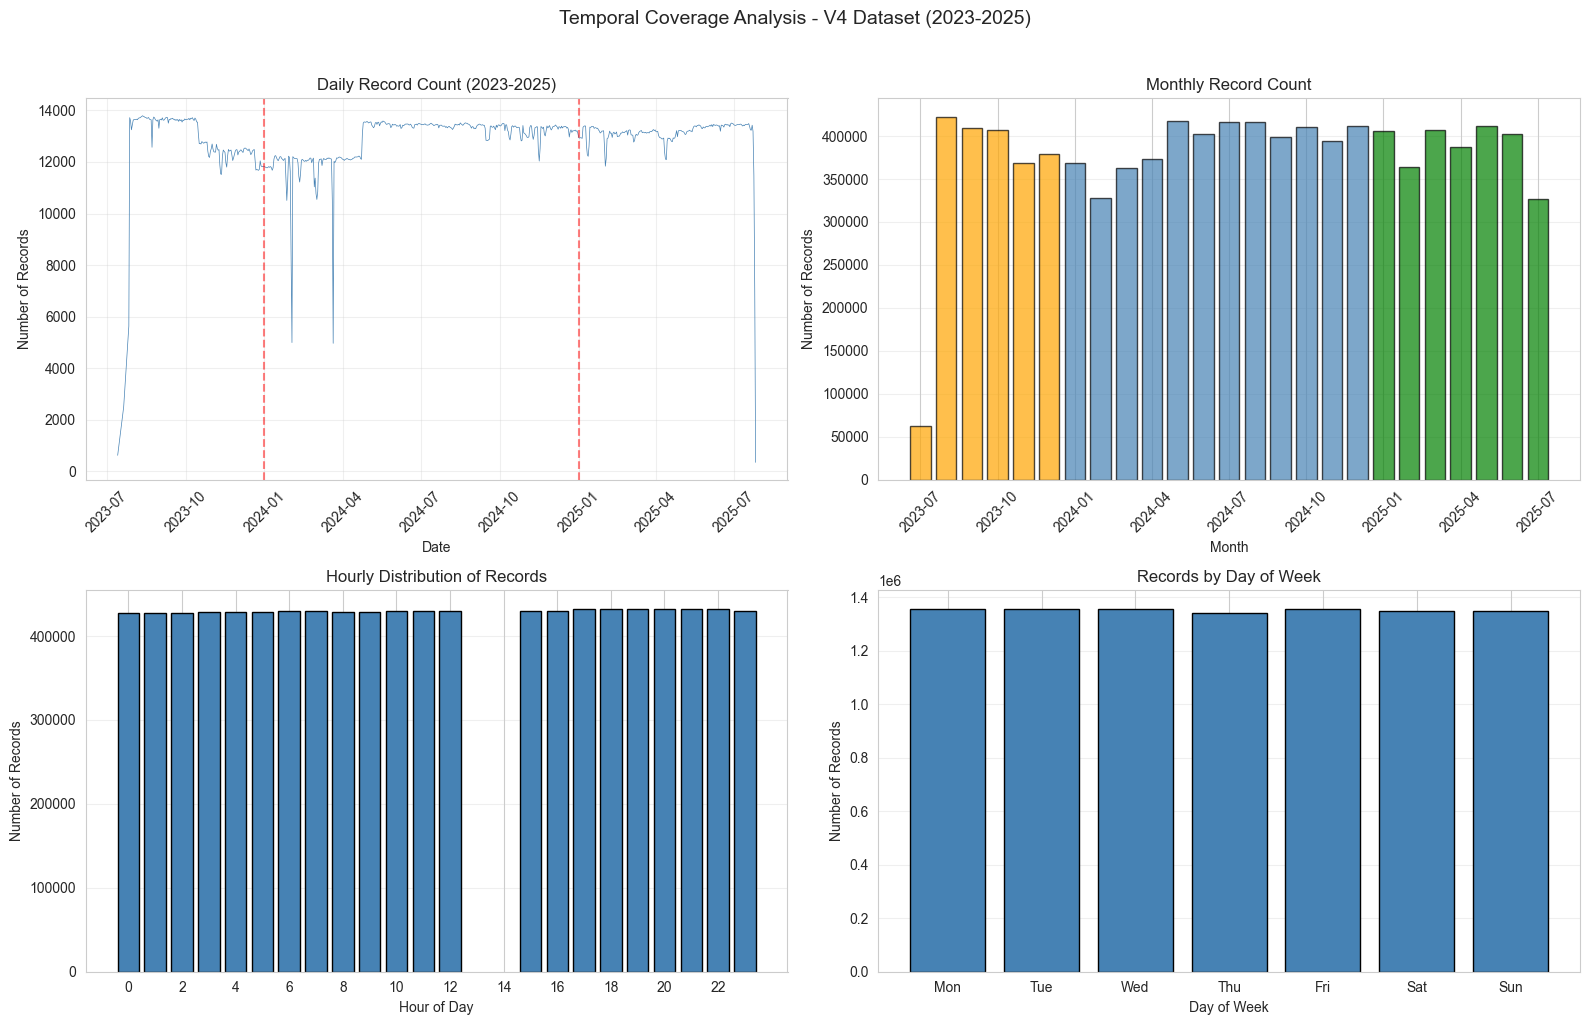


Total unique timestamps: 16,004
Unique hexagons: 634
Average records per hexagon: 14917


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

daily_counts = df.groupby(df['timestamp'].dt.date).size()
axes[0, 0].plot(daily_counts.index, daily_counts.values, linewidth=0.5, color='steelblue')
axes[0, 0].set_title('Daily Record Count (2023-2025)', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Number of Records')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

for year in [2024, 2025]:
    year_start = pd.Timestamp(f'{year}-01-01')
    axes[0, 0].axvline(x=year_start, color='red', linestyle='--', alpha=0.5)

monthly_totals = df.groupby(df['timestamp'].dt.to_period('M')).size()
colors = ['orange' if '2023' in str(idx) else 'steelblue' if '2024' in str(idx) else 'green' 
          for idx in monthly_totals.index]
axes[0, 1].bar(range(len(monthly_totals)), monthly_totals.values, color=colors, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Monthly Record Count', fontsize=12)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Records')
axes[0, 1].set_xticks(range(0, len(monthly_totals), 3))
axes[0, 1].set_xticklabels([str(idx) for idx in monthly_totals.index][::3], rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

hourly_counts = df.groupby('hour').size()
axes[1, 0].bar(hourly_counts.index, hourly_counts.values, color='steelblue', edgecolor='black')
axes[1, 0].set_title('Hourly Distribution of Records', fontsize=12)
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Number of Records')
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(True, alpha=0.3, axis='y')

weekday_counts = df.groupby('day_of_week').size()
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 1].bar(range(7), weekday_counts.reindex(range(7), fill_value=0).values, 
               color='steelblue', edgecolor='black')
axes[1, 1].set_title('Records by Day of Week', fontsize=12)
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Number of Records')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(weekday_names)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Temporal Coverage Analysis - V4 Dataset (2023-2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nTotal unique timestamps: {df['timestamp'].nunique():,}")
print(f"Unique hexagons: {df['hex7_id'].nunique():,}")
print(f"Average records per hexagon: {len(df) / df['hex7_id'].nunique():.0f}")

## 3. Missing Data Analysis

In [6]:
missing_stats = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Available Count': df.notnull().sum(),
    'Available %': (df.notnull().sum() / len(df) * 100).round(2)
})
missing_stats = missing_stats.sort_values('Missing %', ascending=False)

print("Missing Data Summary:")
print("="*60)
display(missing_stats[missing_stats['Missing Count'] > 0])

Missing Data Summary:


,Missing Count,Missing %,Available Count,Available %
pm25_ugm3_mean,1839574,19.45,7617538,80.55
pm25_ugm3_min,1839574,19.45,7617538,80.55
pm25_ugm3_max,1839574,19.45,7617538,80.55
pm25_range,1839574,19.45,7617538,80.55
solar_radiation_wm2_mean,396266,4.19,9060846,95.81
precipitation_mm_mean,365792,3.87,9091320,96.13
heat_index,365792,3.87,9091320,96.13
weather_distance_km,365792,3.87,9091320,96.13
dew_point_c_mean,365792,3.87,9091320,96.13
cloud_cover_pct_mean,365792,3.87,9091320,96.13


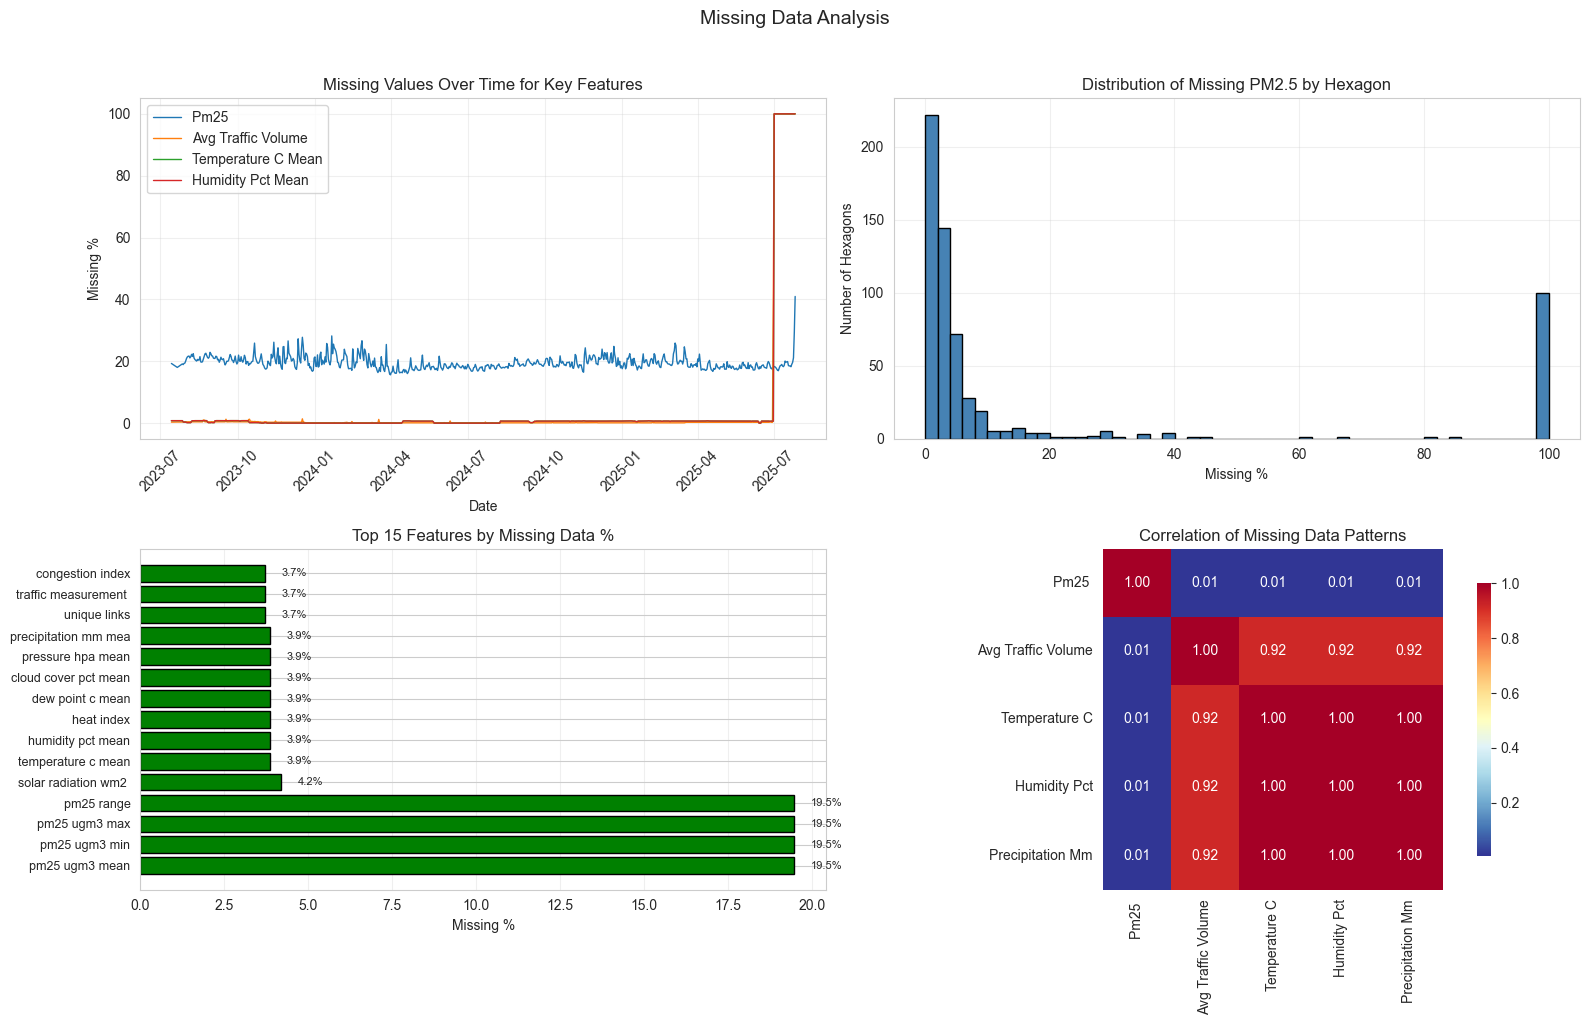

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

key_features = ['pm25_ugm3_mean', 'avg_traffic_volume', 'temperature_c_mean', 'humidity_pct_mean']
for feature in key_features:
    missing_by_time = df.groupby(df['timestamp'].dt.date)[feature].apply(lambda x: x.isnull().mean() * 100)
    axes[0, 0].plot(missing_by_time.index, missing_by_time.values, 
                    label=feature.replace('_', ' ').replace('ugm3 mean', '').title(), linewidth=1)

axes[0, 0].set_title('Missing Values Over Time for Key Features', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Missing %')
axes[0, 0].legend(loc='best')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

missing_by_hex = df.groupby('hex7_id')['pm25_ugm3_mean'].apply(lambda x: x.isnull().mean() * 100)
axes[0, 1].hist(missing_by_hex, bins=50, edgecolor='black', color='steelblue')
axes[0, 1].set_title('Distribution of Missing PM2.5 by Hexagon', fontsize=12)
axes[0, 1].set_xlabel('Missing %')
axes[0, 1].set_ylabel('Number of Hexagons')
axes[0, 1].grid(True, alpha=0.3)

numerical_cols = df.select_dtypes(include=[np.number]).columns
important_cols = [col for col in numerical_cols if 'distance' not in col and 'sin' not in col and 'cos' not in col]
missing_by_feature = df[important_cols].isnull().mean() * 100
missing_by_feature = missing_by_feature.sort_values(ascending=False)[:15]

colors = ['red' if x > 50 else 'orange' if x > 20 else 'green' for x in missing_by_feature.values]
bars = axes[1, 0].barh(range(len(missing_by_feature)), missing_by_feature.values, color=colors, edgecolor='black')
axes[1, 0].set_yticks(range(len(missing_by_feature)))
axes[1, 0].set_yticklabels([col.replace('_', ' ')[:20] for col in missing_by_feature.index], fontsize=9)
axes[1, 0].set_xlabel('Missing %')
axes[1, 0].set_title('Top 15 Features by Missing Data %', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars, missing_by_feature.values)):
    axes[1, 0].text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
                    va='center', fontsize=8)

corr_features = ['pm25_ugm3_mean', 'avg_traffic_volume', 'temperature_c_mean', 
                 'humidity_pct_mean', 'precipitation_mm_mean']
missing_indicators = pd.DataFrame()
for feature in corr_features:
    missing_indicators[feature.replace('_mean', '').replace('ugm3', '').replace('_', ' ').title()] = df[feature].isnull().astype(int)

missing_corr = missing_indicators.corr()
sns.heatmap(missing_corr, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            square=True, cbar_kws={"shrink": 0.8}, ax=axes[1, 1])
axes[1, 1].set_title('Correlation of Missing Data Patterns', fontsize=12)

plt.suptitle('Missing Data Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Distributions

In [8]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")

key_features = ['pm25_ugm3_mean', 'pm25_ugm3_min', 'pm25_ugm3_max', 'pm25_range',
                'avg_traffic_volume', 'max_traffic_volume', 'avg_speed_kmh', 'congestion_index',
                'temperature_c_mean', 'humidity_pct_mean', 'precipitation_mm_mean', 
                'pressure_hpa_mean', 'cloud_cover_pct_mean', 'solar_radiation_wm2_mean']

available_features = [f for f in key_features if f in df.columns]

print("\nBasic Statistics for Key Features:")
display(df[available_features].describe())

Numerical features (37): ['lat', 'lon', 'pm25_ugm3_mean', 'pm25_ugm3_min', 'pm25_ugm3_max', 'pm25_ugm3_count', 'pm25_range', 'avg_traffic_volume', 'max_traffic_volume', 'avg_speed_kmh', 'congestion_index', 'unique_links', 'traffic_measurement_count', 'traffic_distance_km', 'traffic_intensity', 'temperature_c_mean', 'humidity_pct_mean', 'precipitation_mm_mean', 'pressure_hpa_mean', 'cloud_cover_pct_mean', 'dew_point_c_mean', 'solar_radiation_wm2_mean', 'weather_distance_km', 'heat_index', 'is_raining', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'data_completeness_score']

Basic Statistics for Key Features:


,pm25_ugm3_mean,pm25_ugm3_min,pm25_ugm3_max,pm25_range,avg_traffic_volume,max_traffic_volume,avg_speed_kmh,congestion_index,temperature_c_mean,humidity_pct_mean,precipitation_mm_mean,pressure_hpa_mean,cloud_cover_pct_mean,solar_radiation_wm2_mean
count,7617538.00,7617538.00,7617538.00,7617538.00,9105653.00,9105653.00,9105653.00,9105653.00,9091320.00,9091320.00,9091320.00,9091320.00,9091320.00,9060846.00
mean,9.00,8.99,9.01,0.02,34.78,109.98,42.62,7.33,15.80,75.26,0.19,1011.95,59.60,84.96
std,7.99,7.99,7.99,0.38,21.91,70.61,10.94,2.87,9.13,15.03,0.77,7.12,38.95,161.93
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-20.90,10.00,0.00,978.00,0.00,0.00
25%,5.00,5.00,5.00,0.00,12.90,55.91,33.94,5.38,8.10,65.30,0.00,1007.01,18.76,0.00
50%,8.00,8.00,8.00,0.00,36.67,100.59,41.67,8.42,16.17,77.87,0.00,1011.74,70.18,0.00
75%,12.00,12.00,12.00,0.00,52.12,154.43,53.55,10.00,23.66,87.44,0.03,1017.07,99.74,87.05
max,4170.00,4170.00,4170.00,115.00,235.33,5132.23,60.00,10.00,38.02,100.00,45.56,1034.88,100.00,855.25


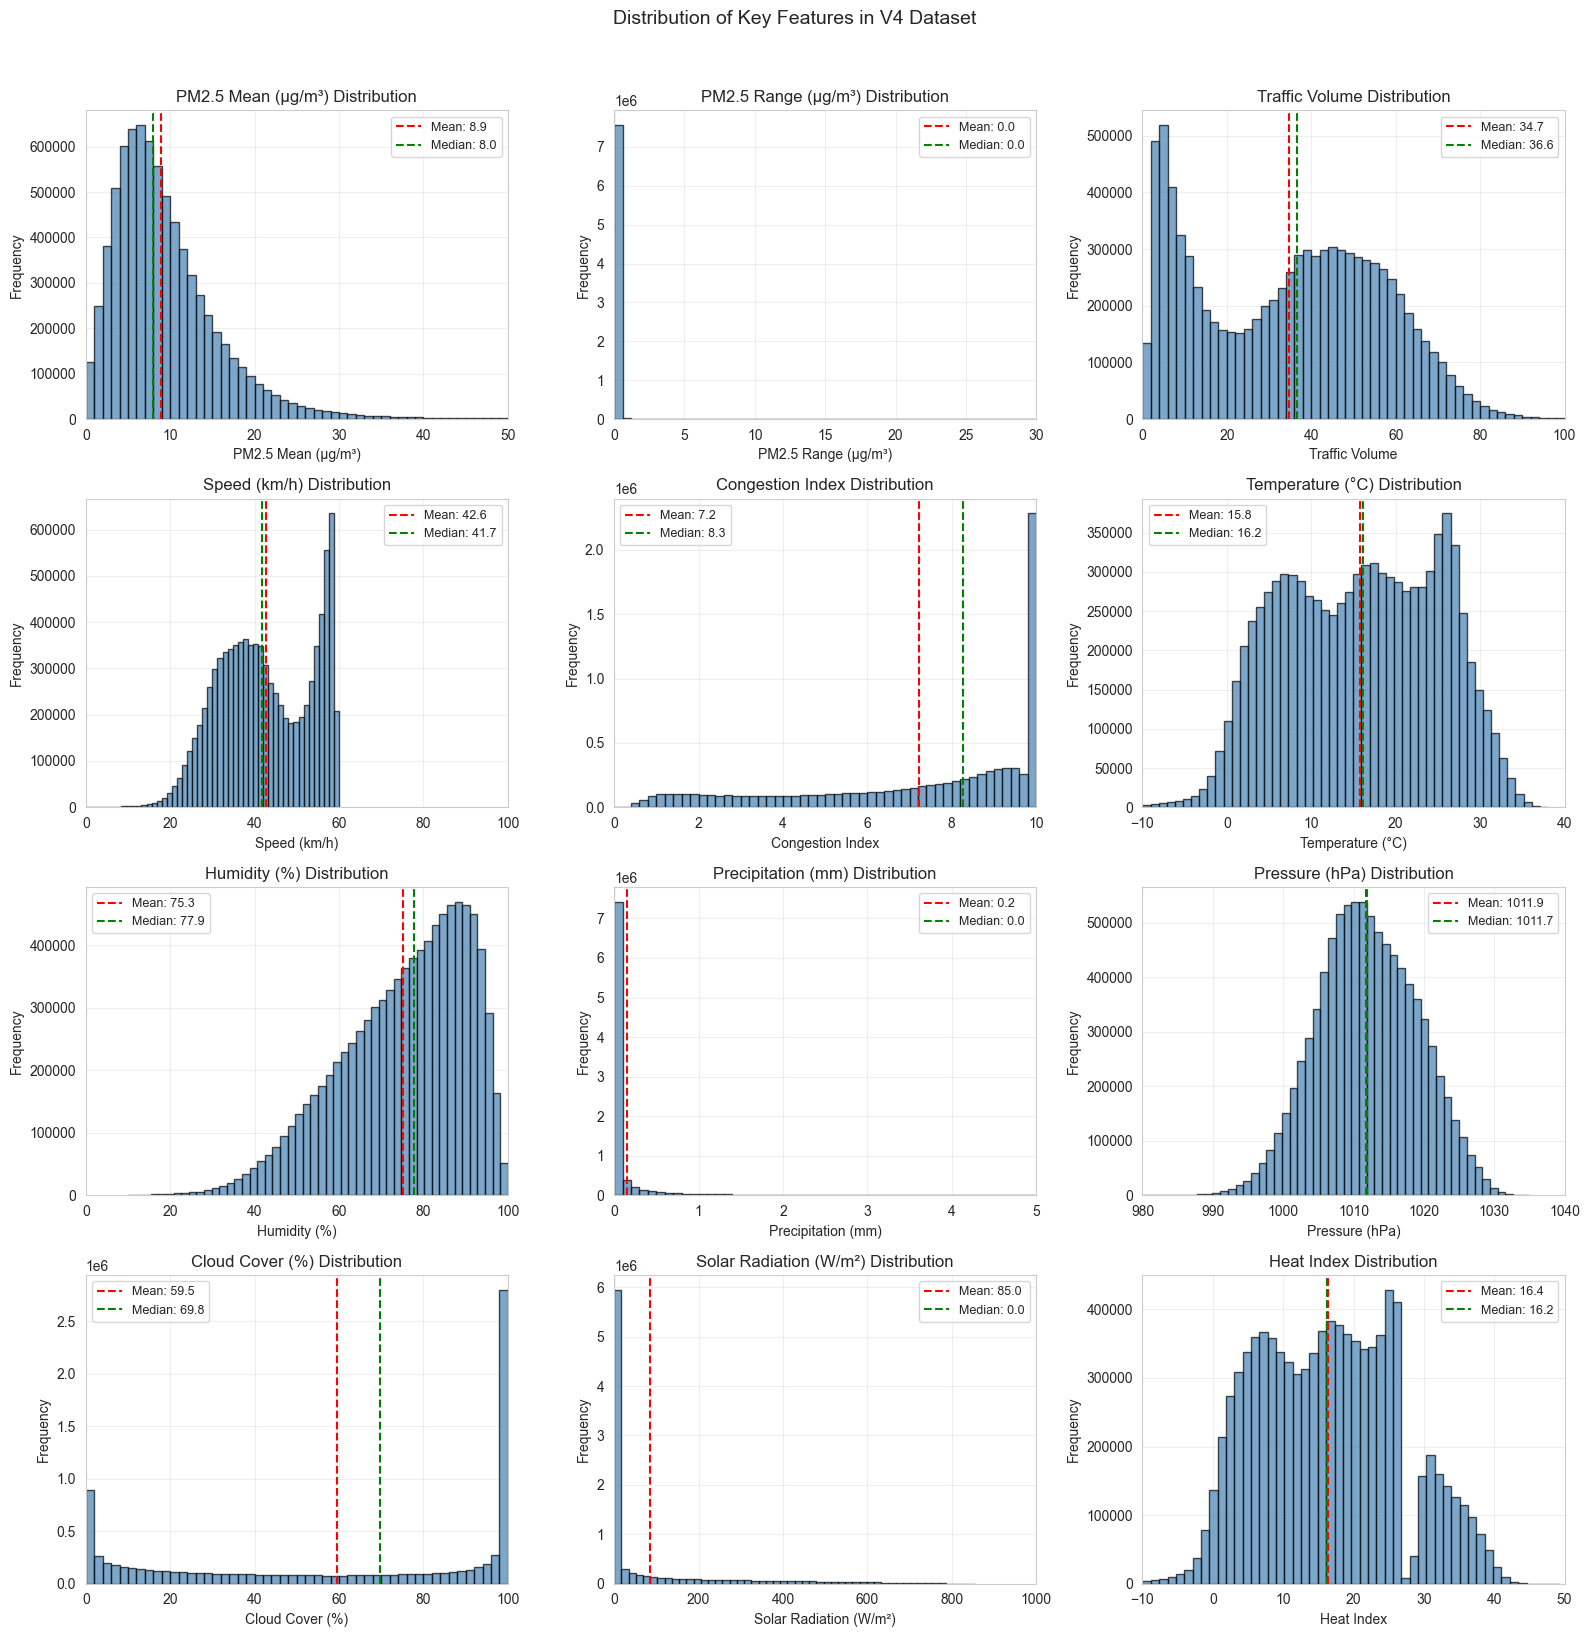

In [9]:
features_to_plot = [
    ('pm25_ugm3_mean', 'PM2.5 Mean (μg/m³)', (0, 50)),
    ('pm25_range', 'PM2.5 Range (μg/m³)', (0, 30)),
    ('avg_traffic_volume', 'Traffic Volume', (0, 100)),
    ('avg_speed_kmh', 'Speed (km/h)', (0, 100)),
    ('congestion_index', 'Congestion Index', (0, 10)),
    ('temperature_c_mean', 'Temperature (°C)', (-10, 40)),
    ('humidity_pct_mean', 'Humidity (%)', (0, 100)),
    ('precipitation_mm_mean', 'Precipitation (mm)', (0, 5)),
    ('pressure_hpa_mean', 'Pressure (hPa)', (980, 1040)),
    ('cloud_cover_pct_mean', 'Cloud Cover (%)', (0, 100)),
    ('solar_radiation_wm2_mean', 'Solar Radiation (W/m²)', (0, 1000)),
    ('heat_index', 'Heat Index', (-10, 50))
]

features_to_plot = [(f, l, x) for f, l, x in features_to_plot if f in df.columns]

n_features = len(features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for idx, (feature, label, xlim) in enumerate(features_to_plot):
    data = df[feature].dropna()
    data = data[np.isfinite(data)]
    
    data_filtered = data[(data >= xlim[0]) & (data <= xlim[1])]
    
    axes[idx].hist(data_filtered, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_xlabel(label)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{label} Distribution')
    axes[idx].set_xlim(xlim)
    
    mean_val = data_filtered.mean()
    median_val = data_filtered.median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.1f}')
    axes[idx].legend(loc='best', fontsize=9)
    axes[idx].grid(True, alpha=0.3)

for j in range(idx+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution of Key Features in V4 Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Temporal Patterns

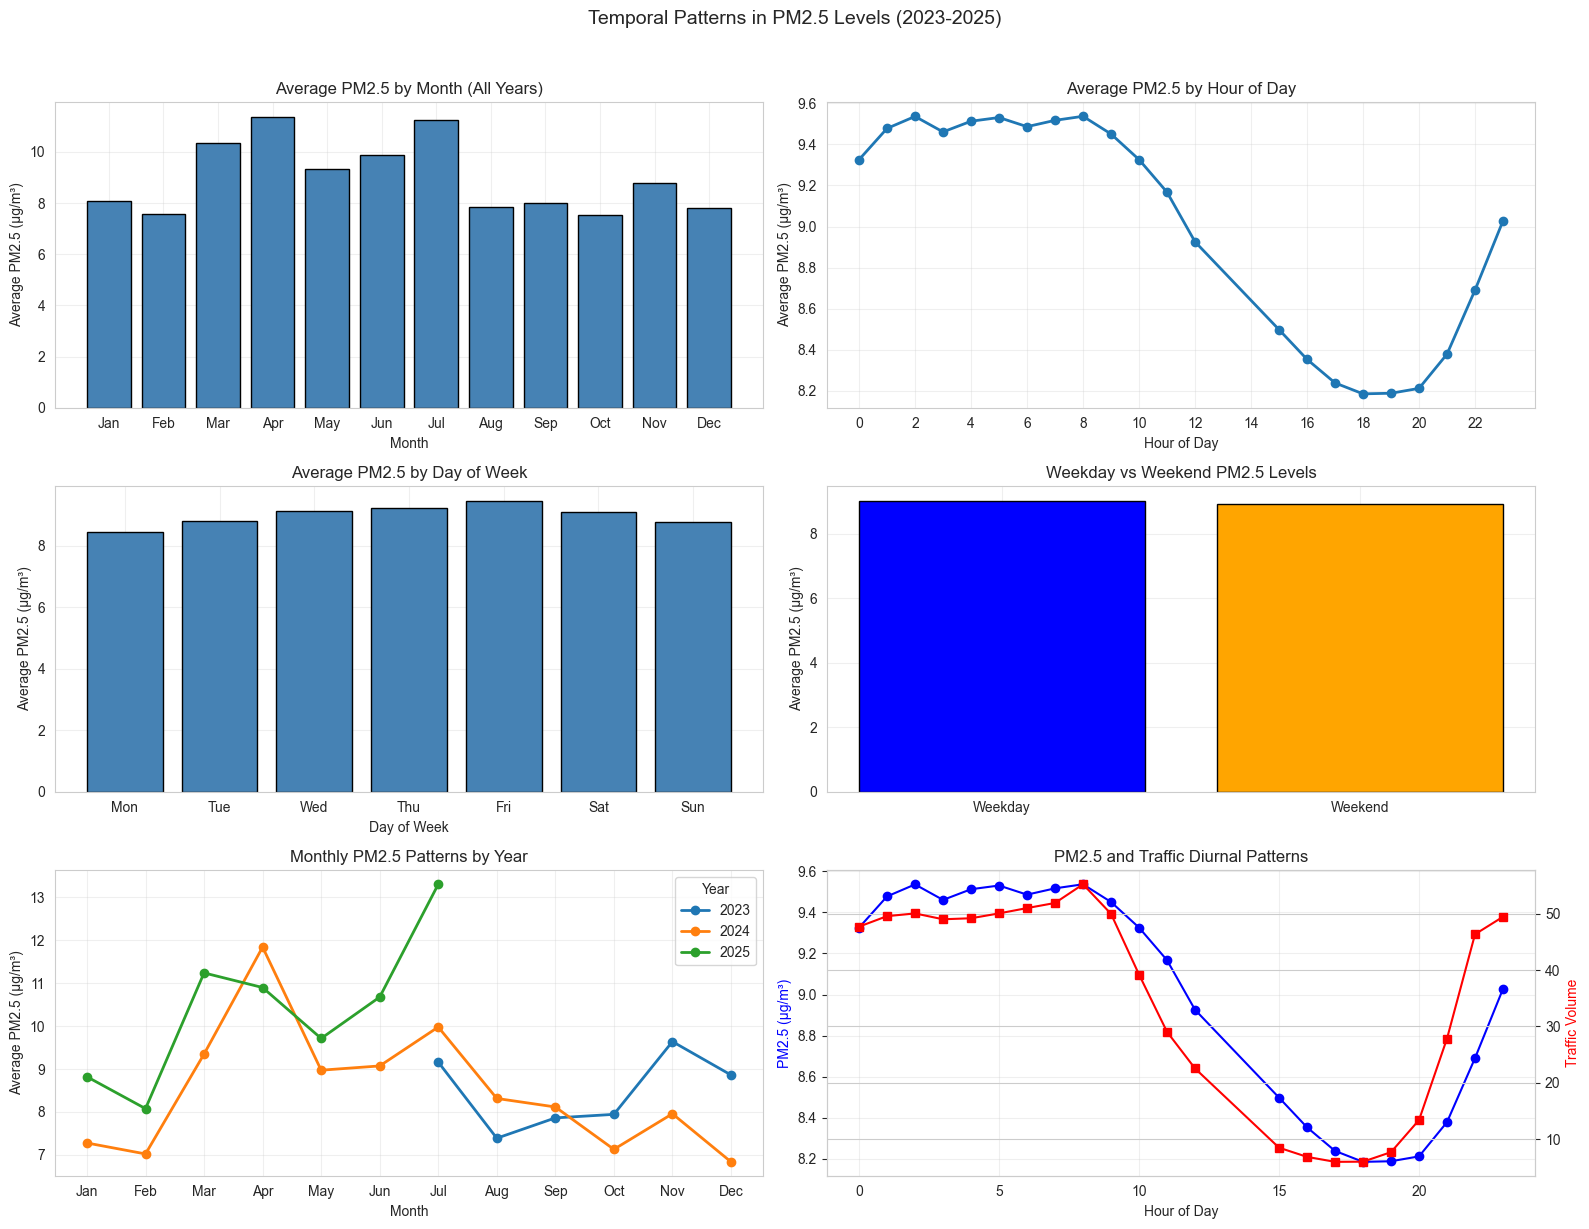

Temporal Statistics:
Highest PM2.5 month: 4 (11.36 μg/m³)
Lowest PM2.5 month: 10 (7.53 μg/m³)
Peak hour: 8:00 (9.54 μg/m³)
Lowest hour: 18:00 (8.19 μg/m³)


In [10]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

monthly_pm25 = df.groupby('month')['pm25_ugm3_mean'].mean()
axes[0, 0].bar(monthly_pm25.index, monthly_pm25.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Average PM2.5 (μg/m³)')
axes[0, 0].set_title('Average PM2.5 by Month (All Years)')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0, 0].grid(True, alpha=0.3)

hourly_pm25 = df.groupby('hour')['pm25_ugm3_mean'].mean()
axes[0, 1].plot(hourly_pm25.index, hourly_pm25.values, marker='o', linewidth=2)
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Average PM2.5 (μg/m³)')
axes[0, 1].set_title('Average PM2.5 by Hour of Day')
axes[0, 1].set_xticks(range(0, 24, 2))
axes[0, 1].grid(True, alpha=0.3)

dow_pm25 = df.groupby('day_of_week')['pm25_ugm3_mean'].mean()
axes[1, 0].bar(dow_pm25.index, dow_pm25.values, color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Average PM2.5 (μg/m³)')
axes[1, 0].set_title('Average PM2.5 by Day of Week')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1, 0].grid(True, alpha=0.3)

weekend_comparison = df.groupby('is_weekend')['pm25_ugm3_mean'].mean()
axes[1, 1].bar(['Weekday', 'Weekend'], weekend_comparison.values, color=['blue', 'orange'], edgecolor='black')
axes[1, 1].set_ylabel('Average PM2.5 (μg/m³)')
axes[1, 1].set_title('Weekday vs Weekend PM2.5 Levels')
axes[1, 1].grid(True, alpha=0.3)

yearly_monthly_pm25 = df.groupby(['year', 'month'])['pm25_ugm3_mean'].mean().unstack(level=0)
yearly_monthly_pm25.plot(ax=axes[2, 0], marker='o', linewidth=2)
axes[2, 0].set_xlabel('Month')
axes[2, 0].set_ylabel('Average PM2.5 (μg/m³)')
axes[2, 0].set_title('Monthly PM2.5 Patterns by Year')
axes[2, 0].set_xticks(range(1, 13))
axes[2, 0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[2, 0].legend(title='Year')
axes[2, 0].grid(True, alpha=0.3)

hourly_traffic = df.groupby('hour')['avg_traffic_volume'].mean()
ax2_1_twin = axes[2, 1].twinx()
axes[2, 1].plot(hourly_pm25.index, hourly_pm25.values, 'b-', marker='o', label='PM2.5')
ax2_1_twin.plot(hourly_traffic.index, hourly_traffic.values, 'r-', marker='s', label='Traffic')
axes[2, 1].set_xlabel('Hour of Day')
axes[2, 1].set_ylabel('PM2.5 (μg/m³)', color='b')
ax2_1_twin.set_ylabel('Traffic Volume', color='r')
axes[2, 1].set_title('PM2.5 and Traffic Diurnal Patterns')
axes[2, 1].grid(True, alpha=0.3)

plt.suptitle('Temporal Patterns in PM2.5 Levels (2023-2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Temporal Statistics:")
print(f"Highest PM2.5 month: {monthly_pm25.idxmax()} ({monthly_pm25.max():.2f} μg/m³)")
print(f"Lowest PM2.5 month: {monthly_pm25.idxmin()} ({monthly_pm25.min():.2f} μg/m³)")
print(f"Peak hour: {hourly_pm25.idxmax()}:00 ({hourly_pm25.max():.2f} μg/m³)")
print(f"Lowest hour: {hourly_pm25.idxmin()}:00 ({hourly_pm25.min():.2f} μg/m³)")

## 6. Geographic Analysis

In [11]:
hex_stats = df.groupby('hex7_id').agg({
    'pm25_ugm3_mean': ['count', 'mean', 'std', lambda x: x.notna().mean()],
    'lat': 'first',
    'lon': 'first',
    'avg_traffic_volume': lambda x: x.notna().mean(),
    'temperature_c_mean': lambda x: x.notna().mean(),
    'traffic_distance_km': 'mean',
    'weather_distance_km': 'mean'
})

hex_stats.columns = ['pm25_count', 'pm25_mean', 'pm25_std', 'pm25_coverage',
                     'lat', 'lon', 'traffic_coverage', 'weather_coverage',
                     'avg_traffic_distance', 'avg_weather_distance']
hex_stats = hex_stats.reset_index()

print(f"Geographic Coverage:")
print(f"  Total hexagons: {len(hex_stats)}")
print(f"  Latitude range: {hex_stats['lat'].min():.2f} to {hex_stats['lat'].max():.2f}")
print(f"  Longitude range: {hex_stats['lon'].min():.2f} to {hex_stats['lon'].max():.2f}")
print(f"\nData completeness by hexagon:")
print(f"  Average PM2.5 coverage: {hex_stats['pm25_coverage'].mean():.1%}")
print(f"  Average traffic coverage: {hex_stats['traffic_coverage'].mean():.1%}")
print(f"  Average weather coverage: {hex_stats['weather_coverage'].mean():.1%}")
print(f"\nDistance to data sources:")
print(f"  Average distance to traffic data: {hex_stats['avg_traffic_distance'].mean():.1f} km")
print(f"  Average distance to weather data: {hex_stats['avg_weather_distance'].mean():.1f} km")

Geographic Coverage:
  Total hexagons: 634
  Latitude range: 24.34 to 45.12
  Longitude range: 124.16 to 144.37

Data completeness by hexagon:
  Average PM2.5 coverage: 80.0%
  Average traffic coverage: 96.2%
  Average weather coverage: 95.8%

Distance to data sources:
  Average distance to traffic data: 6.2 km
  Average distance to weather data: 37.4 km


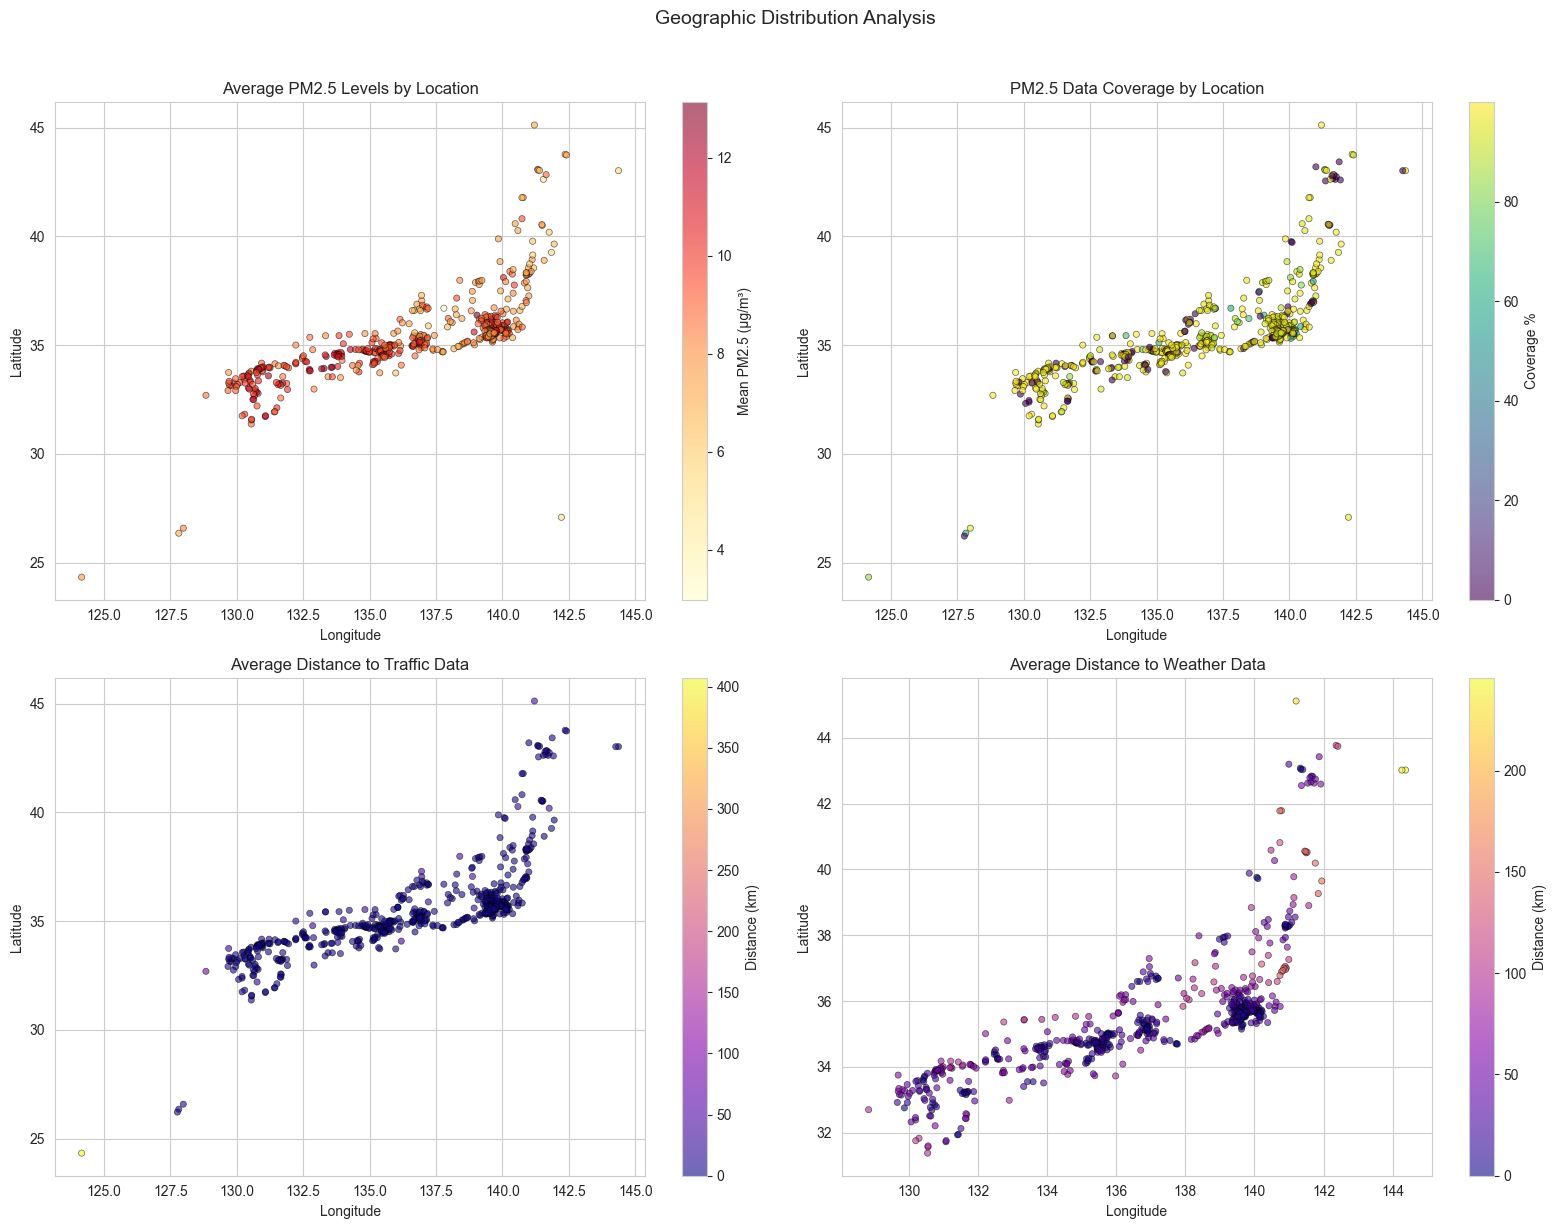

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

scatter1 = axes[0, 0].scatter(hex_stats['lon'], hex_stats['lat'], 
                              c=hex_stats['pm25_mean'], cmap='YlOrRd', 
                              s=20, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')
axes[0, 0].set_title('Average PM2.5 Levels by Location')
plt.colorbar(scatter1, ax=axes[0, 0], label='Mean PM2.5 (μg/m³)')

scatter2 = axes[0, 1].scatter(hex_stats['lon'], hex_stats['lat'], 
                              c=hex_stats['pm25_coverage']*100, cmap='viridis', 
                              s=20, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')
axes[0, 1].set_title('PM2.5 Data Coverage by Location')
plt.colorbar(scatter2, ax=axes[0, 1], label='Coverage %')

scatter3 = axes[1, 0].scatter(hex_stats['lon'], hex_stats['lat'], 
                              c=hex_stats['avg_traffic_distance'], cmap='plasma', 
                              s=20, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')
axes[1, 0].set_title('Average Distance to Traffic Data')
plt.colorbar(scatter3, ax=axes[1, 0], label='Distance (km)')

scatter4 = axes[1, 1].scatter(hex_stats['lon'], hex_stats['lat'], 
                              c=hex_stats['avg_weather_distance'], cmap='plasma', 
                              s=20, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')
axes[1, 1].set_title('Average Distance to Weather Data')
plt.colorbar(scatter4, ax=axes[1, 1], label='Distance (km)')

plt.suptitle('Geographic Distribution Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Feature Correlations

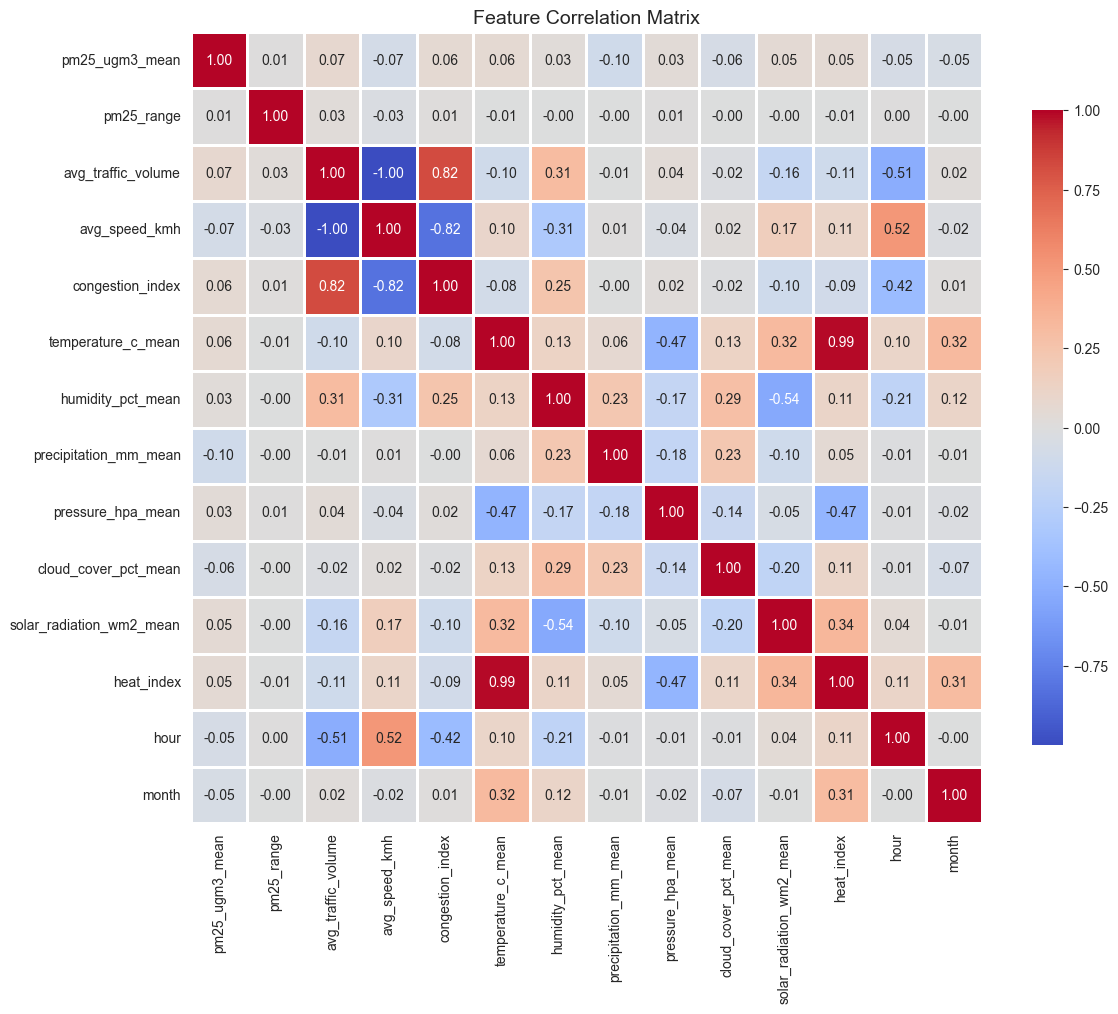

Correlations with PM2.5:
  avg_traffic_volume: 0.071
  congestion_index: 0.062
  temperature_c_mean: 0.056
  solar_radiation_wm2_mean: 0.052
  month: -0.052
  hour: -0.055
  cloud_cover_pct_mean: -0.061
  avg_speed_kmh: -0.071
  precipitation_mm_mean: -0.096


In [13]:
correlation_features = ['pm25_ugm3_mean', 'pm25_range', 'avg_traffic_volume', 'avg_speed_kmh',
                       'congestion_index', 'temperature_c_mean', 'humidity_pct_mean', 
                       'precipitation_mm_mean', 'pressure_hpa_mean', 'cloud_cover_pct_mean',
                       'solar_radiation_wm2_mean', 'heat_index', 'hour', 'month']

available_corr_features = [f for f in correlation_features if f in df.columns]

corr_matrix = df[available_corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

pm25_corr = corr_matrix['pm25_ugm3_mean'].sort_values(ascending=False)
print("Correlations with PM2.5:")
for feature, corr in pm25_corr.items():
    if feature != 'pm25_ugm3_mean' and abs(corr) > 0.05:
        print(f"  {feature}: {corr:.3f}")

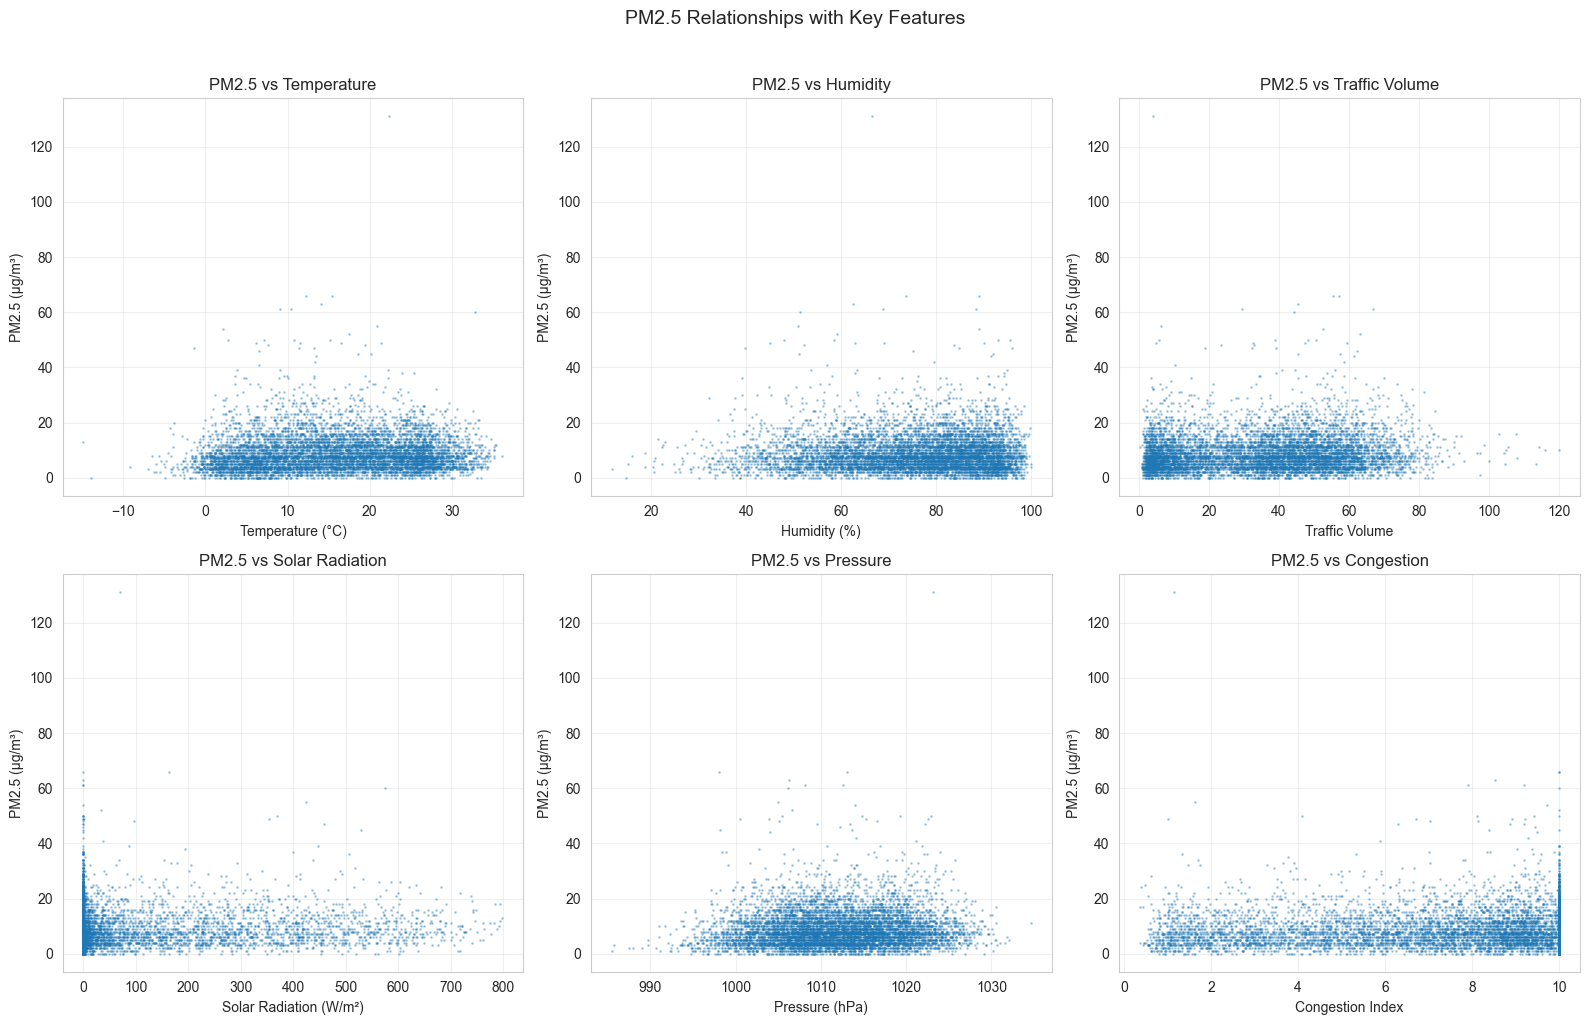

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sample_data = df.sample(min(10000, len(df)))

axes[0, 0].scatter(sample_data['temperature_c_mean'], sample_data['pm25_ugm3_mean'], 
                   alpha=0.3, s=1)
axes[0, 0].set_xlabel('Temperature (°C)')
axes[0, 0].set_ylabel('PM2.5 (μg/m³)')
axes[0, 0].set_title('PM2.5 vs Temperature')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(sample_data['humidity_pct_mean'], sample_data['pm25_ugm3_mean'], 
                   alpha=0.3, s=1)
axes[0, 1].set_xlabel('Humidity (%)')
axes[0, 1].set_ylabel('PM2.5 (μg/m³)')
axes[0, 1].set_title('PM2.5 vs Humidity')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].scatter(sample_data['avg_traffic_volume'], sample_data['pm25_ugm3_mean'], 
                   alpha=0.3, s=1)
axes[0, 2].set_xlabel('Traffic Volume')
axes[0, 2].set_ylabel('PM2.5 (μg/m³)')
axes[0, 2].set_title('PM2.5 vs Traffic Volume')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].scatter(sample_data['solar_radiation_wm2_mean'], sample_data['pm25_ugm3_mean'], 
                   alpha=0.3, s=1)
axes[1, 0].set_xlabel('Solar Radiation (W/m²)')
axes[1, 0].set_ylabel('PM2.5 (μg/m³)')
axes[1, 0].set_title('PM2.5 vs Solar Radiation')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(sample_data['pressure_hpa_mean'], sample_data['pm25_ugm3_mean'], 
                   alpha=0.3, s=1)
axes[1, 1].set_xlabel('Pressure (hPa)')
axes[1, 1].set_ylabel('PM2.5 (μg/m³)')
axes[1, 1].set_title('PM2.5 vs Pressure')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].scatter(sample_data['congestion_index'], sample_data['pm25_ugm3_mean'], 
                   alpha=0.3, s=1)
axes[1, 2].set_xlabel('Congestion Index')
axes[1, 2].set_ylabel('PM2.5 (μg/m³)')
axes[1, 2].set_title('PM2.5 vs Congestion')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('PM2.5 Relationships with Key Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Multi-Year Comparison

In [15]:
yearly_stats = df.groupby('year').agg({
    'pm25_ugm3_mean': ['count', 'mean', 'std', 'min', 'max', 
                       lambda x: x.quantile(0.25), lambda x: x.quantile(0.50), 
                       lambda x: x.quantile(0.75), lambda x: x.quantile(0.95)],
    'avg_traffic_volume': ['mean', 'std'],
    'temperature_c_mean': ['mean', 'std'],
    'humidity_pct_mean': ['mean', 'std']
})

yearly_stats.columns = ['_'.join(col).strip() for col in yearly_stats.columns.values]

print("Yearly Comparison Statistics:")
print("="*60)
display(yearly_stats)

Yearly Comparison Statistics:


,pm25_ugm3_mean_count,pm25_ugm3_mean_mean,pm25_ugm3_mean_std,pm25_ugm3_mean_min,pm25_ugm3_mean_max,pm25_ugm3_mean_<lambda_0>,pm25_ugm3_mean_<lambda_1>,pm25_ugm3_mean_<lambda_2>,pm25_ugm3_mean_<lambda_3>,avg_traffic_volume_mean,avg_traffic_volume_std,temperature_c_mean_mean,temperature_c_mean_std,humidity_pct_mean_mean,humidity_pct_mean_std
year,,,,,,,,,,,,,,,
2023,1625989,8.33,6.60,0.00,3089.00,4.00,7.00,11.00,19.00,34.99,21.93,18.62,8.83,75.88,13.80
2024,3798955,8.51,8.12,0.00,4170.00,4.00,7.00,11.00,19.00,34.75,21.88,16.41,9.12,76.56,14.15
2025,2192594,10.34,8.51,0.00,2985.00,5.00,9.00,14.00,25.00,34.64,21.93,12.15,8.23,72.16,17.13


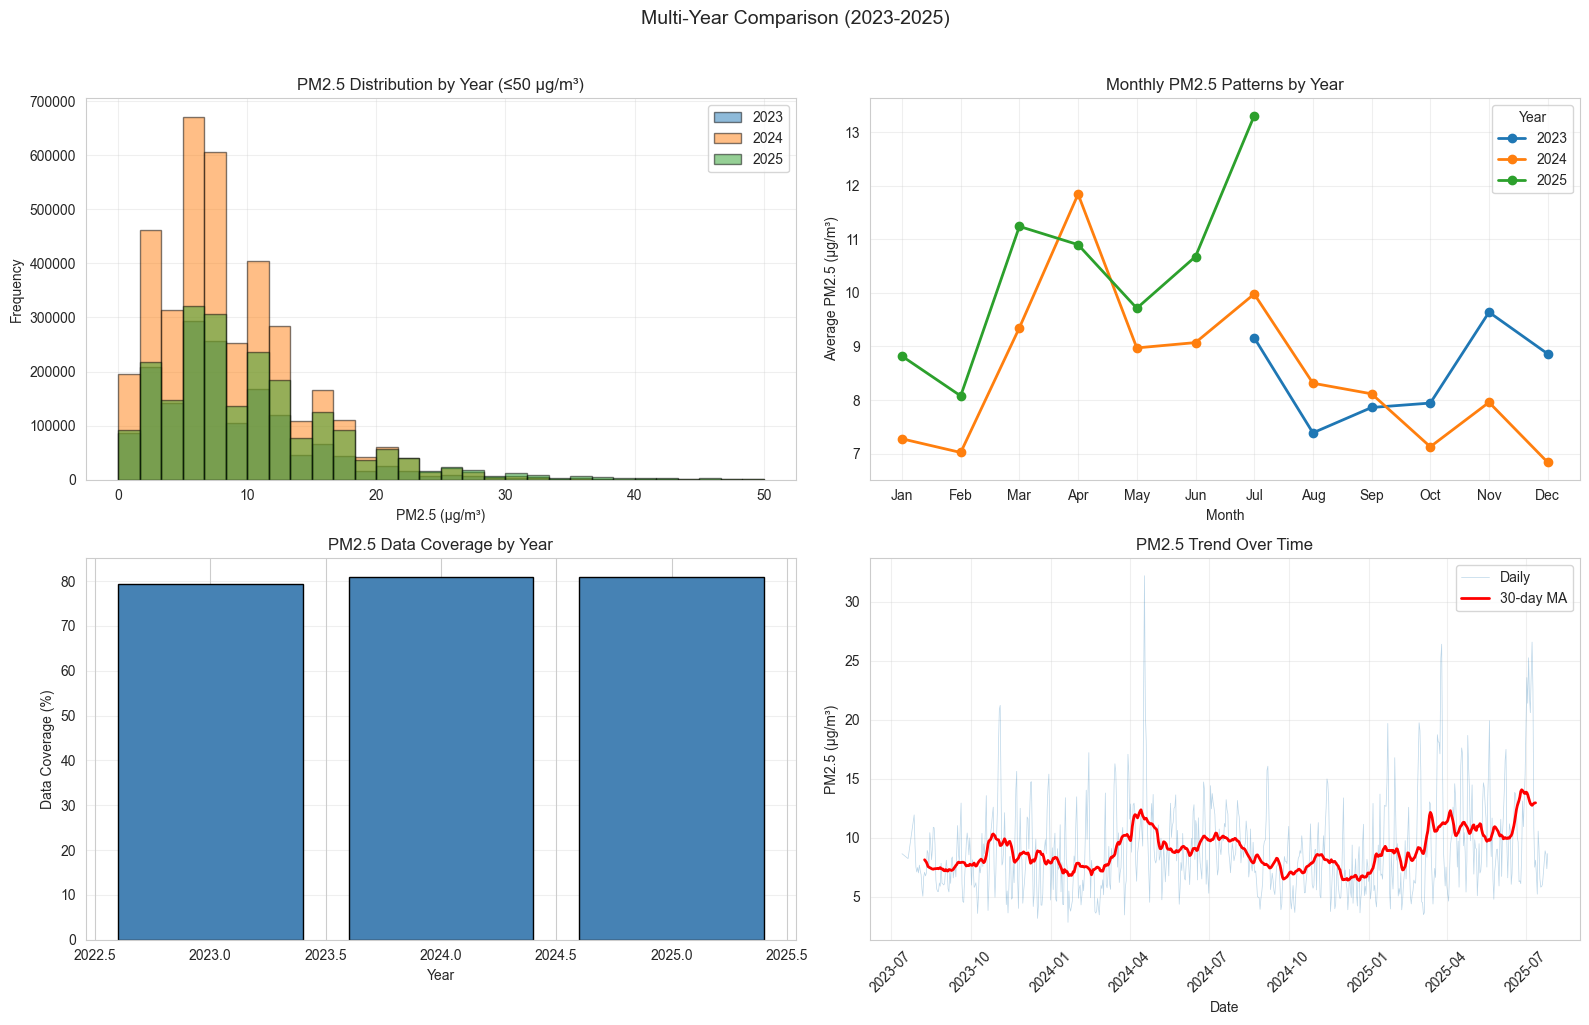

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for year in df['year'].unique():
    year_data = df[df['year'] == year]['pm25_ugm3_mean'].dropna()
    year_data_filtered = year_data[year_data <= 50]
    axes[0, 0].hist(year_data_filtered, bins=30, alpha=0.5, label=str(year), edgecolor='black')

axes[0, 0].set_xlabel('PM2.5 (μg/m³)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('PM2.5 Distribution by Year (≤50 μg/m³)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

yearly_monthly_pm25 = df.groupby(['year', 'month'])['pm25_ugm3_mean'].mean().unstack(level=0)
yearly_monthly_pm25.plot(ax=axes[0, 1], marker='o', linewidth=2)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average PM2.5 (μg/m³)')
axes[0, 1].set_title('Monthly PM2.5 Patterns by Year')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0, 1].legend(title='Year')
axes[0, 1].grid(True, alpha=0.3)

yearly_coverage = df.groupby('year')['pm25_ugm3_mean'].apply(lambda x: x.notna().mean() * 100)
axes[1, 0].bar(yearly_coverage.index, yearly_coverage.values, color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Data Coverage (%)')
axes[1, 0].set_title('PM2.5 Data Coverage by Year')
axes[1, 0].grid(True, alpha=0.3, axis='y')

daily_pm25 = df.groupby(df['timestamp'].dt.date)['pm25_ugm3_mean'].mean()
rolling_mean = daily_pm25.rolling(window=30, center=True).mean()
axes[1, 1].plot(daily_pm25.index, daily_pm25.values, alpha=0.3, linewidth=0.5, label='Daily')
axes[1, 1].plot(rolling_mean.index, rolling_mean.values, linewidth=2, color='red', label='30-day MA')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('PM2.5 (μg/m³)')
axes[1, 1].set_title('PM2.5 Trend Over Time')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Multi-Year Comparison (2023-2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Pollution Analysis

In [17]:
WHO_ANNUAL_GUIDELINE = 5
WHO_24H_GUIDELINE = 15
JAPAN_STANDARD = 35

print("Air Quality Standards Analysis:")
print("="*60)

exceedance_who_annual = (df['pm25_ugm3_mean'] > WHO_ANNUAL_GUIDELINE).mean() * 100
exceedance_who_24h = (df['pm25_ugm3_mean'] > WHO_24H_GUIDELINE).mean() * 100
exceedance_japan = (df['pm25_ugm3_mean'] > JAPAN_STANDARD).mean() * 100

print(f"Exceedance rates:")
print(f"  WHO Annual Guideline (5 μg/m³): {exceedance_who_annual:.1f}%")
print(f"  WHO 24-hour Guideline (15 μg/m³): {exceedance_who_24h:.1f}%")
print(f"  Japan Standard (35 μg/m³): {exceedance_japan:.1f}%")

pm25_percentiles = df['pm25_ugm3_mean'].quantile([0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
print("\nPM2.5 Percentiles:")
for percentile, value in pm25_percentiles.items():
    print(f"  {percentile*100:.0f}th percentile: {value:.2f} μg/m³")

pollution_categories = pd.cut(df['pm25_ugm3_mean'], 
                             bins=[0, 12, 35.4, 55.4, 150.4, 250.4, float('inf')],
                             labels=['Good', 'Moderate', 'Unhealthy for Sensitive',
                                    'Unhealthy', 'Very Unhealthy', 'Hazardous'])

print("\nAir Quality Index Distribution:")
for category, count in pollution_categories.value_counts().items():
    percentage = count / len(pollution_categories.dropna()) * 100
    print(f"  {category}: {count:,} ({percentage:.1f}%)")

Air Quality Standards Analysis:
Exceedance rates:
  WHO Annual Guideline (5 μg/m³): 54.1%
  WHO 24-hour Guideline (15 μg/m³): 10.4%
  Japan Standard (35 μg/m³): 0.5%

PM2.5 Percentiles:
  5th percentile: 2.00 μg/m³
  25th percentile: 5.00 μg/m³
  50th percentile: 8.00 μg/m³
  75th percentile: 12.00 μg/m³
  95th percentile: 21.00 μg/m³
  99th percentile: 32.00 μg/m³

Air Quality Index Distribution:
  Good: 5,810,257 (77.6%)
  Moderate: 1,633,539 (21.8%)
  Unhealthy for Sensitive: 42,121 (0.6%)
  Unhealthy: 5,731 (0.1%)
  Hazardous: 126 (0.0%)
  Very Unhealthy: 68 (0.0%)


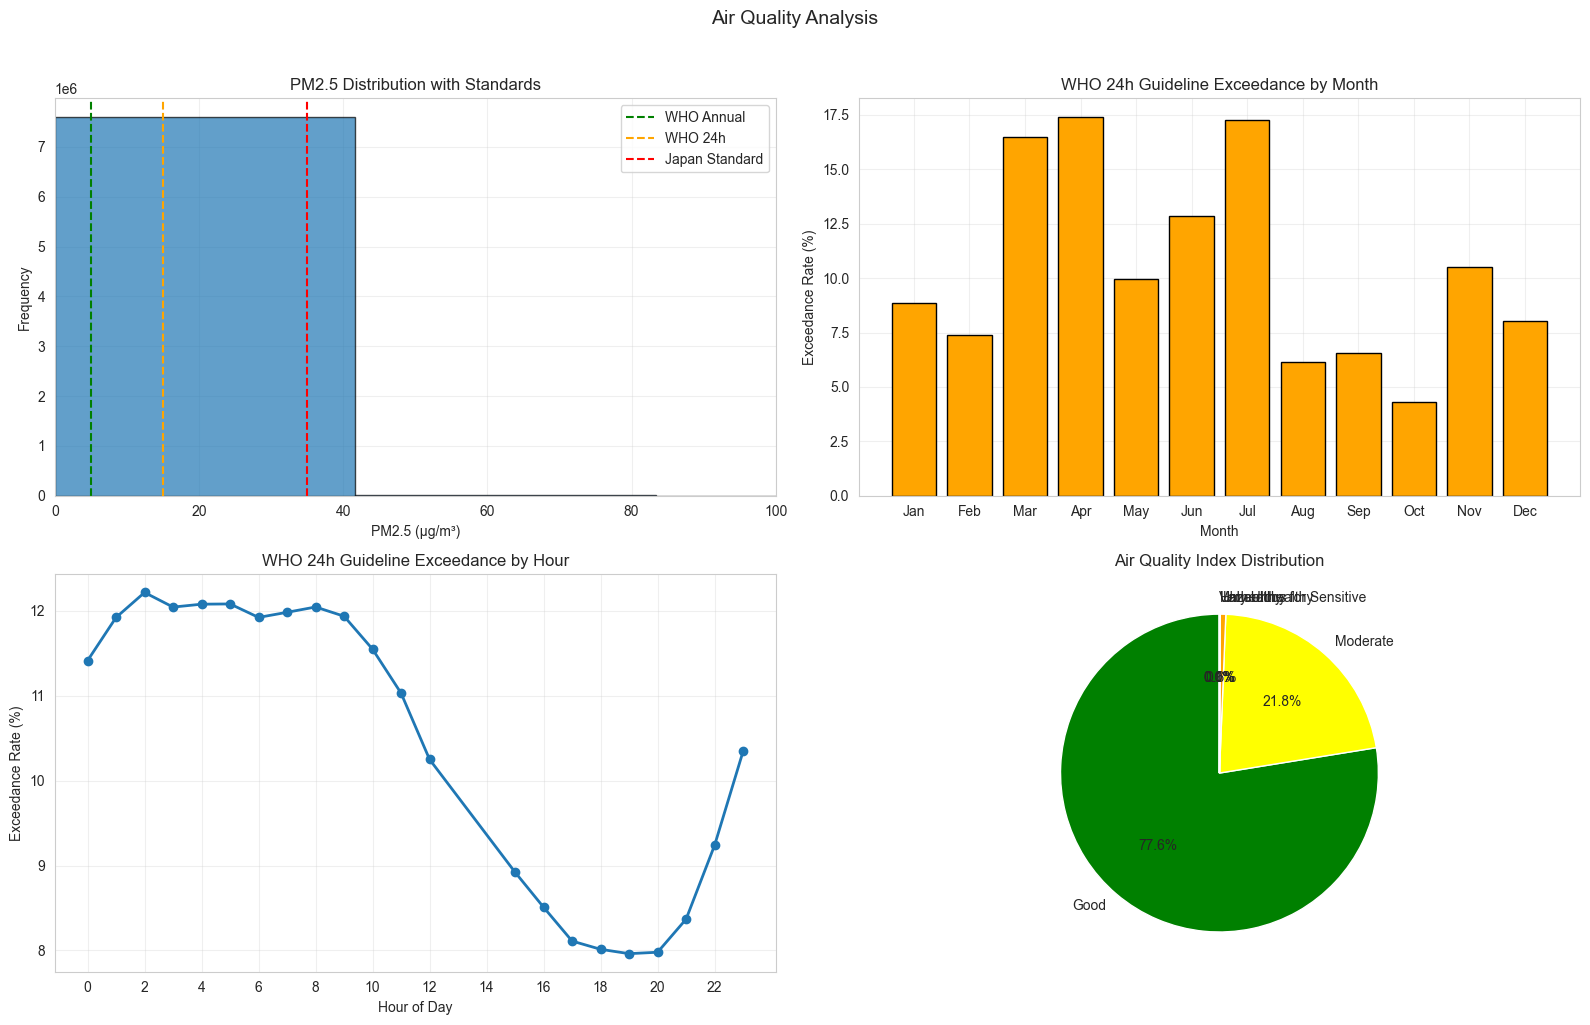

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(df['pm25_ugm3_mean'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(WHO_ANNUAL_GUIDELINE, color='green', linestyle='--', label='WHO Annual')
axes[0, 0].axvline(WHO_24H_GUIDELINE, color='orange', linestyle='--', label='WHO 24h')
axes[0, 0].axvline(JAPAN_STANDARD, color='red', linestyle='--', label='Japan Standard')
axes[0, 0].set_xlabel('PM2.5 (μg/m³)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('PM2.5 Distribution with Standards')
axes[0, 0].set_xlim(0, 100)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

pollution_by_month = df.groupby('month').apply(
    lambda x: (x['pm25_ugm3_mean'] > WHO_24H_GUIDELINE).mean() * 100
)
axes[0, 1].bar(pollution_by_month.index, pollution_by_month.values, color='orange', edgecolor='black')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Exceedance Rate (%)')
axes[0, 1].set_title('WHO 24h Guideline Exceedance by Month')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0, 1].grid(True, alpha=0.3)

pollution_by_hour = df.groupby('hour').apply(
    lambda x: (x['pm25_ugm3_mean'] > WHO_24H_GUIDELINE).mean() * 100
)
axes[1, 0].plot(pollution_by_hour.index, pollution_by_hour.values, marker='o', linewidth=2)
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Exceedance Rate (%)')
axes[1, 0].set_title('WHO 24h Guideline Exceedance by Hour')
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(True, alpha=0.3)

category_colors = {'Good': 'green', 'Moderate': 'yellow', 'Unhealthy for Sensitive': 'orange',
                  'Unhealthy': 'red', 'Very Unhealthy': 'purple', 'Hazardous': 'maroon'}
category_counts = pollution_categories.value_counts()
colors = [category_colors.get(cat, 'gray') for cat in category_counts.index]
axes[1, 1].pie(category_counts.values, labels=category_counts.index, colors=colors,
               autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Air Quality Index Distribution')

plt.suptitle('Air Quality Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Data Quality Assessment

In [19]:
print("DATA QUALITY ASSESSMENT")
print("="*80)

print("\n1. OVERALL COMPLETENESS:")
print(f"   Total records: {len(df):,}")
print(f"   PM2.5 available: {df['pm25_ugm3_mean'].notna().sum():,} ({df['pm25_ugm3_mean'].notna().mean():.1%})")
print(f"   Traffic available: {df['avg_traffic_volume'].notna().sum():,} ({df['avg_traffic_volume'].notna().mean():.1%})")
print(f"   Weather available: {df['temperature_c_mean'].notna().sum():,} ({df['temperature_c_mean'].notna().mean():.1%})")

complete_mask = df[['pm25_ugm3_mean', 'avg_traffic_volume', 'temperature_c_mean']].notna().all(axis=1)
print(f"   Complete records (all features): {complete_mask.sum():,} ({complete_mask.mean():.1%})")

print("\n2. DATA SOURCE QUALITY:")
local_traffic = (df['traffic_distance_km'] == 0).sum()
local_weather = (df['weather_distance_km'] == 0).sum()
print(f"   Records with local traffic data: {local_traffic:,} ({local_traffic/len(df)*100:.1f}%)")
print(f"   Records with local weather data: {local_weather:,} ({local_weather/len(df)*100:.1f}%)")
print(f"   Mean distance to traffic: {df['traffic_distance_km'].mean():.1f} km")
print(f"   Mean distance to weather: {df['weather_distance_km'].mean():.1f} km")

print("\n3. TEMPORAL CONSISTENCY:")
time_diffs = df.groupby('hex7_id')['timestamp'].apply(lambda x: x.sort_values().diff().dt.total_seconds() / 3600)
print(f"   Most common sampling interval: {time_diffs.dropna().mode().values[0]:.0f} hours")
print(f"   Median sampling interval: {time_diffs.dropna().median():.1f} hours")

print("\n4. OUTLIER DETECTION:")
for col in ['pm25_ugm3_mean', 'avg_traffic_volume', 'temperature_c_mean']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"   {col}: {outliers:,} outliers ({outliers/df[col].notna().sum()*100:.2f}%)")

print("\n5. FEATURE ENGINEERING VALIDATION:")
print(f"   Cyclical encodings present: {all(col in df.columns for col in ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'])}")
print(f"   Heat index calculated: {'heat_index' in df.columns}")
print(f"   PM2.5 range calculated: {'pm25_range' in df.columns}")
print(f"   Traffic intensity present: {'traffic_intensity' in df.columns}")
print(f"   Data completeness score: {'data_completeness_score' in df.columns}")

DATA QUALITY ASSESSMENT

1. OVERALL COMPLETENESS:
   Total records: 9,457,112
   PM2.5 available: 7,617,538 (80.5%)
   Traffic available: 9,105,653 (96.3%)
   Weather available: 9,091,320 (96.1%)
   Complete records (all features): 7,317,792 (77.4%)

2. DATA SOURCE QUALITY:
   Records with local traffic data: 372,547 (3.9%)
   Records with local weather data: 103,874 (1.1%)
   Mean distance to traffic: 5.9 km
   Mean distance to weather: 38.1 km

3. TEMPORAL CONSISTENCY:
   Most common sampling interval: 1 hours
   Median sampling interval: 1.0 hours

4. OUTLIER DETECTION:
   pm25_ugm3_mean: 286,226 outliers (3.76%)
   avg_traffic_volume: 3,336 outliers (0.04%)
   temperature_c_mean: 301 outliers (0.00%)

5. FEATURE ENGINEERING VALIDATION:
   Cyclical encodings present: True
   Heat index calculated: True
   PM2.5 range calculated: True
   Traffic intensity present: True
   Data completeness score: True


## 11. Summary Statistics Export

In [20]:
summary_stats = {
    'Total Records': len(df),
    'Date Range Start': df['timestamp'].min(),
    'Date Range End': df['timestamp'].max(),
    'Unique Hexagons': df['hex7_id'].nunique(),
    'Unique Timestamps': df['timestamp'].nunique(),
    
    'PM2.5 Mean': df['pm25_ugm3_mean'].mean(),
    'PM2.5 Median': df['pm25_ugm3_mean'].median(),
    'PM2.5 Std': df['pm25_ugm3_mean'].std(),
    'PM2.5 Min': df['pm25_ugm3_mean'].min(),
    'PM2.5 Max': df['pm25_ugm3_mean'].max(),
    'PM2.5 Coverage': df['pm25_ugm3_mean'].notna().mean(),
    
    'Traffic Mean': df['avg_traffic_volume'].mean(),
    'Traffic Coverage': df['avg_traffic_volume'].notna().mean(),
    
    'Temperature Mean': df['temperature_c_mean'].mean(),
    'Temperature Coverage': df['temperature_c_mean'].notna().mean(),
    
    'Complete Records': complete_mask.mean(),
    'WHO Annual Exceedance': exceedance_who_annual,
    'WHO 24h Exceedance': exceedance_who_24h,
    'Japan Standard Exceedance': exceedance_japan
}

summary_df = pd.DataFrame([summary_stats])
summary_df.to_csv(f'{data_path}v4_summary_statistics.csv', index=False)
print("Summary statistics saved to v4_summary_statistics.csv")

display(summary_df.T)

Summary statistics saved to v4_summary_statistics.csv


,0
Total Records,9457112
Date Range Start,2023-07-14 16:00:00+00:00
Date Range End,2025-07-26 05:00:00+00:00
Unique Hexagons,634
Unique Timestamps,16004
PM2.5 Mean,9.00
PM2.5 Median,8.00
PM2.5 Std,7.99
PM2.5 Min,0.00
PM2.5 Max,4170.00


## 12. Final Summary

In [ ]:
print("="*80)
print("PM2.5 ENRICHED DATASET V4 - COMPREHENSIVE EDA COMPLETE")
print("="*80)

print("\n📊 DATASET OVERVIEW:")
print(f"   Total records: {len(df):,}")
print(f"   Time period: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"   Unique locations: {df['hex7_id'].nunique()}")
print(f"   Total features: {len(df.columns)}")

print("\n📈 PM2.5 STATISTICS:")
pm25_clean = df['pm25_ugm3_mean'].dropna()
print(f"   Mean: {pm25_clean.mean():.2f} μg/m³")
print(f"   Median: {pm25_clean.median():.2f} μg/m³")
print(f"   95th percentile: {pm25_clean.quantile(0.95):.2f} μg/m³")
print(f"   WHO guideline exceedance: {exceedance_who_24h:.1f}%")

print("\n✅ DATA COMPLETENESS:")
print(f"   PM2.5: {df['pm25_ugm3_mean'].notna().mean():.1%}")
print(f"   Traffic: {df['avg_traffic_volume'].notna().mean():.1%}")
print(f"   Weather: {df['temperature_c_mean'].notna().mean():.1%}")
print(f"   All features: {complete_mask.mean():.1%}")

print("\n🌍 GEOGRAPHIC COVERAGE:")
print(f"   Hexagons: {df['hex7_id'].nunique()}")
print(f"   Latitude range: {df['lat'].min():.2f}° to {df['lat'].max():.2f}°")
print(f"   Longitude range: {df['lon'].min():.2f}° to {df['lon'].max():.2f}°")

print("\n📅 TEMPORAL COVERAGE:")
print(f"   Years: {sorted(df['year'].unique())}")
print(f"   Months with data: {df['timestamp'].dt.to_period('M').nunique()}")

print("\n🎯 KEY FINDINGS:")
print(f"   Peak pollution month: {monthly_pm25.idxmax()}")
print(f"   Peak pollution hour: {hourly_pm25.idxmax()}:00")
print(f"   Weekend effect: {'Lower' if weekend_comparison[1] < weekend_comparison[0] else 'Higher'} on weekends")

print("\n💾 DATASET READY FOR:")
print("   • Advanced time series modeling (LSTM, GRU, Transformer)")
print("   • Spatial-temporal analysis")
print("   • Multi-year trend analysis")
print("   • Air quality forecasting")
print("   • Feature importance analysis")

print("\n📁 OUTPUT FILES:")
print(f"   • {os.path.basename(file_to_load)}")
print(f"   • v4_summary_statistics.csv")
print("="*80)

PM2.5 ENRICHED DATASET V4 - COMPREHENSIVE EDA COMPLETE

📊 DATASET OVERVIEW:
   Total records: 9,457,112
   Time period: 2023-07-14 to 2025-07-26
   Unique locations: 634
   Total features: 39

📈 PM2.5 STATISTICS:
   Mean: 9.00 μg/m³
   Median: 8.00 μg/m³
   95th percentile: 21.00 μg/m³
   WHO guideline exceedance: 10.4%

✅ DATA COMPLETENESS:
   PM2.5: 80.5%
   Traffic: 96.3%
   Weather: 96.1%
   All features: 77.4%

🌍 GEOGRAPHIC COVERAGE:
   Hexagons: 634
   Latitude range: 24.34° to 45.12°
   Longitude range: 124.16° to 144.37°

📅 TEMPORAL COVERAGE:
   Years: [np.int64(2023), np.int64(2024), np.int64(2025)]
   Months with data: 25

🎯 KEY FINDINGS:
   Peak pollution month: 4
   Peak pollution hour: 8:00
   Weekend effect: Lower on weekends

💾 DATASET READY FOR:
   • Advanced time series modeling (LSTM, GRU, Transformer)
   • Spatial-temporal analysis
   • Multi-year trend analysis
   • Air quality forecasting
   • Feature importance analysis

📁 OUTPUT FILES:
   • pm25_enriched_2023_202

: 